TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
/content/im2latex
/content/im2latex
formula_images.tar. 100%[===================>] 278.62M  21.1MB/s    in 14s     
im2latex_formulas.l 100%[===================>]  11.75M  5.86MB/s    in 2.0s    
im2latex_train.lst  100%[===================>]   1.83M  1.58MB/s    in 1.2s    
im2latex_validate.l 100%[===================>] 208.66K   412KB/s    in 0.5s    
im2latex_test.lst   100%[===================>] 231.82K   347KB/s    in 0.7s    
formula_images.tar.gz -> True 278.62 MB
im2latex_formulas.lst -> True 11.75 MB
im2latex_train.lst -> True 1.83 MB
im2latex_validate.lst -> True 0.20 MB
im2latex_test.lst -> True 0.23 MB


/tmp/ipykernel_786/3455996050.py:116: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(


Распаковка завершена.
PNG изображений: 103536
Первый файл: /content/im2latex/formula_images/5bba9dc476.png
Формул: 103559

0 \int_{-\epsilon}^\infty dl\: {\rm e}^{-l\zeta}	\int_{-\epsilon}^\infty dl' {\rm e}^{-l'\zeta}	ll'{l'-l \over l+l'} \{3\,\delta''(l) - {3 \over 4}t\,\delta(l) \} =0.		\label{eq21}
1 ds^{2} = (1 - {qcos\theta\over r})^{2\over 1 + \alpha^{2}}\lbrace dr^2+r^2d\theta^2+r^2sin^2\theta d\varphi^2\rbrace -{dt^2\over  (1 - {qcos\theta\over r})^{2\over 1 + \alpha^{2}}}\, .\label{eq:sps1}
2 \widetilde\gamma_{\rm hopf}\simeq\sum_{n>0}\widetilde{G}_n{(-a)^n\over2^{2n-1}}\label{H4}
3 ({\cal L}_a g)_{ij} = 0, \ \ \ \ ({\cal L}_a H)_{ijk} = 0 ,
4 S_{stat} = 2\pi \sqrt{N_5^{(1)} N_5^{(2)} N_5^{(3)}} \left(\sqrt{n} +\sqrt{\bar{n}}\right)\label{74}
Всего формул: 103559
Пустых формул: 0

0: \int_{-\epsilon}^\infty dl\: {\rm e}^{-l\zeta}	\int_{-\epsilon}^\infty dl' {\rm e}^{-l'\zeta}	ll'{l'-l \over l+l'} \{3\,\delta''(l) - {3 \over 4}t\,\d
1: ds^{2} = (1 - {qcos\theta\over r})^{2\ove

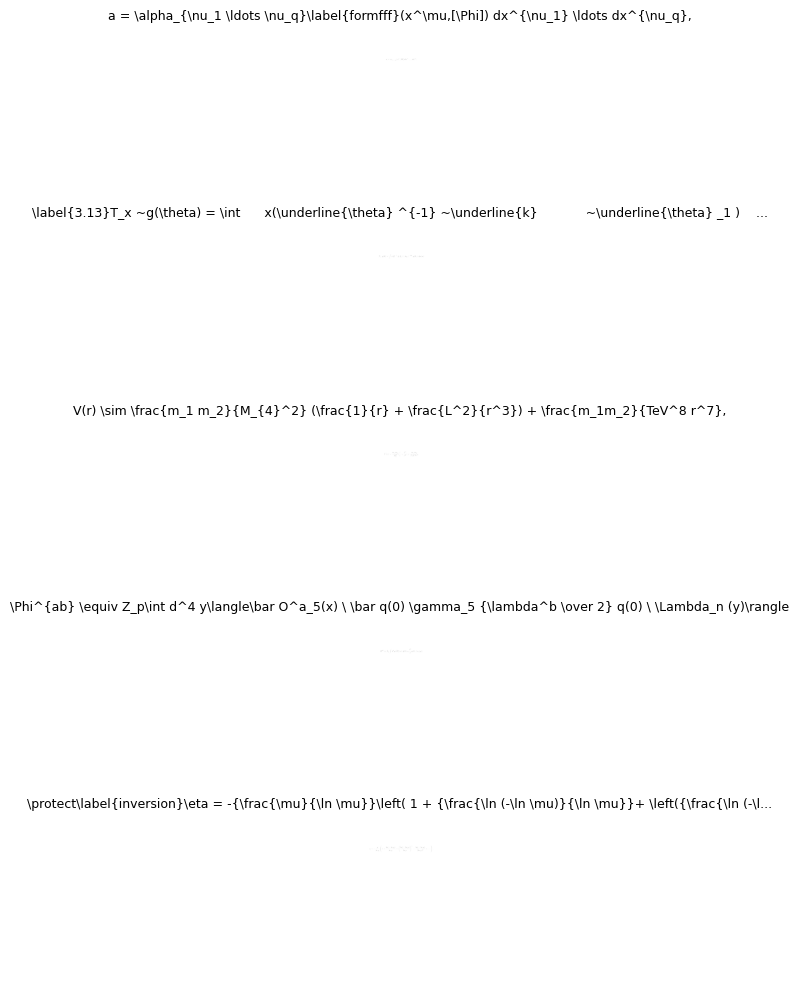

Image: 628e76a0d4.png
LaTeX:
a = \alpha_{\nu_1 \ldots \nu_q}\label{formfff}(x^\mu,[\Phi]) dx^{\nu_1} \ldots dx^{\nu_q},

Image: 4959ddf375.png
LaTeX:
\label{3.13}T_x ~g(\theta) = \int      x(\underline{\theta} ^{-1} ~\underline{k}            ~\underline{\theta} _1 )    ~ {\mid k_{22} \mid }^{-2k} ~g (\theta _1)     ~d \mu (u)

Image: 55a0ce1675.png
LaTeX:
V(r) \sim \frac{m_1 m_2}{M_{4}^2} (\frac{1}{r} + \frac{L^2}{r^3}) + \frac{m_1m_2}{TeV^8 r^7},

Image: 780007c559.png
LaTeX:
\Phi^{ab} \equiv Z_p\int d^4 y\langle\bar O^a_5(x) \ \bar q(0) \gamma_5 {\lambda^b \over 2} q(0) \ \Lambda_n (y)\rangle

Image: 3043dc1d05.png
LaTeX:
\protect\label{inversion}\eta = -{\frac{\mu}{\ln \mu}}\left( 1 + {\frac{\ln (-\ln \mu)}{\ln \mu}}+ \left({\frac{\ln (-\ln \mu)}{\ln \mu}}\right)^2 - {\frac{\ln (-\ln\mu)}{(\ln \mu)^2}} + \cdots \right) .



In [ ]:
# 1. Импорты

import os
import random
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


# 2. Параметры

SEED = 42

TRAIN_LIMIT = 20000
VAL_LIMIT = 2000
TEST_LIMIT = 1000

BATCH_SIZE = 32
EPOCHS = 15

EMBED_DIM = 256
UNITS = 512
ATTENTION_UNITS = 512

IMG_HEIGHT = 128
IMG_WIDTH = 512

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(
    "TensorFlow:",
    tf.__version__
)

print(
    "GPU:",
    tf.config.list_physical_devices("GPU")
)


# 3. Рабочая папка

DATA_DIR = Path(
    "/content/im2latex"
)

DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    DATA_DIR
)

# 4. Загрузка датасета

%cd /content/im2latex

!wget -q --show-progress \
    -O formula_images.tar.gz \
    "https://zenodo.org/records/56198/files/formula_images.tar.gz?download=1"

!wget -q --show-progress \
    -O im2latex_formulas.lst \
    "https://zenodo.org/records/56198/files/im2latex_formulas.lst?download=1"

!wget -q --show-progress \
    -O im2latex_train.lst \
    "https://zenodo.org/records/56198/files/im2latex_train.lst?download=1"

!wget -q --show-progress \
    -O im2latex_validate.lst \
    "https://zenodo.org/records/56198/files/im2latex_validate.lst?download=1"

!wget -q --show-progress \
    -O im2latex_test.lst \
    "https://zenodo.org/records/56198/files/im2latex_test.lst?download=1"



# 5. Проверка файлов

for file_name in [
    "formula_images.tar.gz",
    "im2latex_formulas.lst",
    "im2latex_train.lst",
    "im2latex_validate.lst",
    "im2latex_test.lst",
]:

    file_path = (
        DATA_DIR
        / file_name
    )

    print(
        file_name,
        "->",
        file_path.exists(),
        f"{file_path.stat().st_size / 1024 / 1024:.2f} MB"
        if file_path.exists()
        else ""
    )



# 6. Распаковка изображений

archive_path = (
    DATA_DIR
    / "formula_images.tar.gz"
)

with tarfile.open(
    archive_path,
    "r:gz",
) as archive:

    archive.extractall(
        DATA_DIR
    )

print(
    "Распаковка завершена."
)



# 7. Поиск изображений

image_files = list(
    DATA_DIR.rglob(
        "*.png"
    )
)

print(
    "PNG изображений:",
    len(image_files)
)

print(
    "Первый файл:",
    image_files[0]
)



# 8. Чтение формул

formulas_path = (
    DATA_DIR
    / "im2latex_formulas.lst"
)

with open(
    formulas_path,
    "r",
    encoding="latin-1",
    newline="\n",
) as file:

    formulas = [
        line.rstrip("\n")
        for line in file
    ]

print(
    "Формул:",
    len(formulas)
)

print()

for index in range(5):

    print(
        index,
        formulas[index]
    )


# 9. Проверка формул

empty_formulas = sum(
    1
    for formula in formulas
    if not formula.strip()
)

print(
    "Всего формул:",
    len(formulas)
)

print(
    "Пустых формул:",
    empty_formulas
)

print()

for index in [
    0,
    1,
    2,
    100,
    1000,
]:

    print(
        f"{index}:",
        formulas[index][:150]
    )



# 10. Парсер split-файлов

def load_split(
    file_path,
):

    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8",
    ) as file:

        for line in file:

            parts = (
                line.strip()
                .split()
            )

            if len(parts) < 2:
                continue

            formula_index = int(
                parts[0]
            )

            image_name = (
                parts[1]
                + ".png"
            )

            render_type = (
                parts[2]
                if len(parts) > 2
                else ""
            )

            records.append(
                {
                    "formula_index":
                        formula_index,

                    "image":
                        image_name,

                    "render_type":
                        render_type,

                    "formula":
                        formulas[
                            formula_index
                        ],
                }
            )

    return pd.DataFrame(
        records
    )



# 11. Train / validation / test

train_df = load_split(
    DATA_DIR
    / "im2latex_train.lst"
)

val_df = load_split(
    DATA_DIR
    / "im2latex_validate.lst"
)

test_df = load_split(
    DATA_DIR
    / "im2latex_test.lst"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)



# 12. Ограничение выборки

train_df = (
    train_df
    .sample(
        n=min(
            TRAIN_LIMIT,
            len(train_df)
        ),
        random_state=SEED,
    )
    .reset_index(
        drop=True
    )
)

val_df = (
    val_df
    .sample(
        n=min(
            VAL_LIMIT,
            len(val_df)
        ),
        random_state=SEED,
    )
    .reset_index(
        drop=True
    )
)

test_df = (
    test_df
    .sample(
        n=min(
            TEST_LIMIT,
            len(test_df)
        ),
        random_state=SEED,
    )
    .reset_index(
        drop=True
    )
)

print(
    "Используем train:",
    len(train_df)
)

print(
    "Используем validation:",
    len(val_df)
)

print(
    "Используем test:",
    len(test_df)
)


# 13. Карта изображений

image_path_by_name = {
    path.name: path
    for path in image_files
}

print(
    "Файлов в словаре:",
    len(image_path_by_name)
)


# 14. Проверка соответствия

missing_images = [
    image_name
    for image_name
    in train_df[
        "image"
    ]
    if image_name
    not in image_path_by_name
]

print(
    "Не найдено:",
    len(missing_images)
)



# 15. Просмотр примеров

sample_df = train_df.sample(
    5,
    random_state=SEED,
)

plt.figure(
    figsize=(14, 10)
)

for plot_index, (_, row) in enumerate(
    sample_df.iterrows(),
    start=1,
):

    image_path = (
        image_path_by_name[
            row["image"]
        ]
    )

    image_data = plt.imread(
        image_path
    )

    plt.subplot(
        5,
        1,
        plot_index,
    )

    plt.imshow(
        image_data,
        cmap="gray",
    )

    plt.axis(
        "off"
    )

    formula = (
        row["formula"]
    )

    if len(formula) > 120:

        formula = (
            formula[:120]
            + "..."
        )

    plt.title(
        formula,
        fontsize=9,
    )

plt.tight_layout()
plt.show()



# 16. Проверка пар

for _, row in sample_df.iterrows():

    print(
        "=" * 80
    )

    print(
        "Image:",
        row["image"]
    )

    print(
        "LaTeX:"
    )

    print(
        row["formula"]
    )

    print()





Было:
B_{\mu\nu}(x) \rightarrow B_{\mu\nu}(x) + \partial_\mu F_\nu(x) - \partial_\nu F_\mu (x)\label{n2}

Стало:
B_{\mu\nu}(x) \rightarrow B_{\mu\nu}(x) + \partial_\mu F_\nu(x) - \partial_\nu F_\mu (x)
--------------------------------------------------------------------------------
Было:
\label{A.17}\Gamma[g,A]=-\frac 14 \int d^3x\sqrt{g}\left[{1 \over 4\pi G}(R-2\Lambda) -F^{\mu\nu}F_{\mu\nu}+aR^{\mu\nu}R_{\mu\nu}+b R^2\right]~~~.

Стало:
\Gamma[g,A]=-\frac 14 \int d^3x\sqrt{g}\left[{1 \over 4\pi G}(R-2\Lambda) -F^{\mu\nu}F_{\mu\nu}+aR^{\mu\nu}R_{\mu\nu}+b R^2\right]~~~.
--------------------------------------------------------------------------------
Было:
\label{qclas} \left\{Q^-_n,Q^+_n\right\}_{PB}=-i(H_n)^n, \qquad \{Q^\pm_n,H_n\}_{PB}=0.

Стало:
\left\{Q^-_n,Q^+_n\right\}_{PB}=-i(H_n)^n, \qquad \{Q^\pm_n,H_n\}_{PB}=0.
--------------------------------------------------------------------------------
Было:
\tilde g_{\mu\nu} =	e^{2\phi} g_{\mu\nu} \label{rescale}

Стало:
\tilde g_{\m

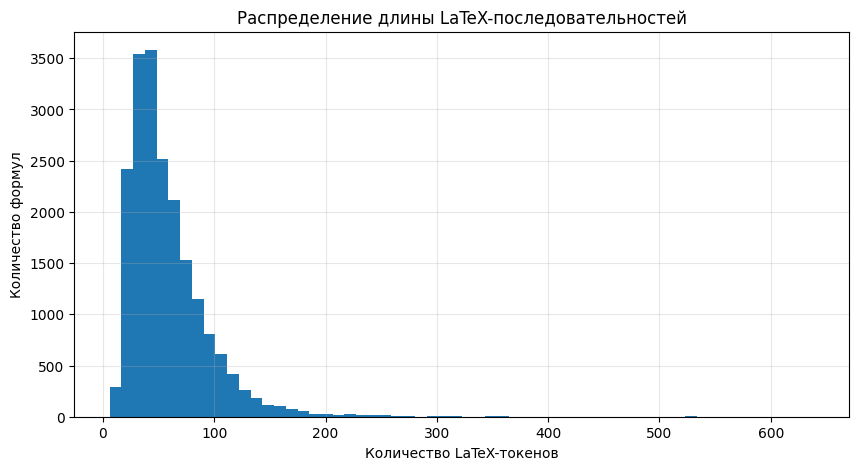

MAX_SEQ_LEN: 124
Train:
20000 -> 19033 (95.2%)
Validation:
2000 -> 1898 (94.9%)
Test:
1000 -> 955 (95.5%)
Уникальных токенов: 3613

20 самых частых:
'{' 111009
'}' 111009
'_' 61499
'^' 50785
')' 36109
'(' 36102
'2' 31755
'=' 23703
'-' 23301
'1' 22517
',' 20605
'+' 17282
'\\frac' 12661
'0' 10739
'i' 9417
'.' 9168
'\\,' 8825
'x' 8411
'\\mu' 8066
'\\right' 7152
VOCAB_SIZE: 3617
PAD: 0
UNK: 1
START: 2
END: 3
Покрытие словаря: 100.00%
Токены:
['B', '_', '{', '\\mu', '\\nu', '}', '(', 'x', ')', '\\rightarrow', 'B', '_', '{', '\\mu', '\\nu', '}', '(', 'x', ')', '+', '\\partial', '_', '\\mu', 'F', '_', '\\nu', '(', 'x', ')', '-']

ID:
[2, 86, 6, 4, 22, 44, 5, 9, 21, 8, 151, 86, 6, 4, 22, 44, 5, 9, 21, 8, 15, 28, 6, 22, 72, 6, 44, 9, 21, 8]
Train: (19033, 124)
Validation: (1898, 124)
Test: (955, 124)
Оригинал:
B_{\mu\nu}(x) \rightarrow B_{\mu\nu}(x) + \partial_\mu F_\nu(x) - \partial_\nu F_\mu (x)

После токенизации:
B _ { \mu \nu } ( x ) \rightarrow B _ { \mu \nu } ( x ) + \partial _ \mu F _ \

In [ ]:
# 17. Очистка LaTeX

import re
from collections import Counter


def clean_formula(
    formula,
):

    formula = str(
        formula
    )

    # Удаляем служебный \protect
    formula = re.sub(
        r"\\protect\s*",
        "",
        formula,
    )

    # Удаляем невидимые \label{...}
    formula = re.sub(
        r"\\label\s*\{[^{}]*\}",
        "",
        formula,
    )

    # Нормализуем пробелы и табуляции
    formula = re.sub(
        r"\s+",
        " ",
        formula,
    )

    return formula.strip()



# 18. Проверка очистки

for formula in train_df[
    "formula"
].head(
    10
):

    print(
        "Было:"
    )

    print(
        formula
    )

    print()

    print(
        "Стало:"
    )

    print(
        clean_formula(
            formula
        )
    )

    print(
        "-" * 80
    )



# 19. Очистка всех формул

train_df[
    "formula_clean"
] = train_df[
    "formula"
].apply(
    clean_formula
)

val_df[
    "formula_clean"
] = val_df[
    "formula"
].apply(
    clean_formula
)

test_df[
    "formula_clean"
] = test_df[
    "formula"
].apply(
    clean_formula
)


# 20. Проверка результата

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print()

print(
    train_df[
        [
            "image",
            "formula_clean",
        ]
    ].head()
)


# 21. Шаблон токенизации LaTeX

TOKEN_PATTERN = re.compile(
    r"""
    \\[a-zA-Z]+
    |
    \\[^\s]
    |
    \d+(?:\.\d+)?
    |
    [a-zA-Z]+
    |
    [{}_^]
    |
    [^\s]
    """,
    re.VERBOSE,
)


def tokenize_formula(
    formula,
):

    return TOKEN_PATTERN.findall(
        formula
    )



# 22. Проверка токенизации

example_formula = (
    r"\frac{x^2 + 1}"
    r"{\sqrt{y}}"
)

example_tokens = (
    tokenize_formula(
        example_formula
    )
)

print(
    "Формула:"
)

print(
    example_formula
)

print()

print(
    "Токены:"
)

print(
    example_tokens
)




# 23. Токенизация выборок

train_df[
    "tokens"
] = train_df[
    "formula_clean"
].apply(
    tokenize_formula
)

val_df[
    "tokens"
] = val_df[
    "formula_clean"
].apply(
    tokenize_formula
)

test_df[
    "tokens"
] = test_df[
    "formula_clean"
].apply(
    tokenize_formula
)


# 24. Длина последовательностей

train_df[
    "token_count"
] = train_df[
    "tokens"
].apply(
    len
)

val_df[
    "token_count"
] = val_df[
    "tokens"
].apply(
    len
)

test_df[
    "token_count"
] = test_df[
    "tokens"
].apply(
    len
)



# 25. Статистика длины

train_lengths = (
    train_df[
        "token_count"
    ].to_numpy()
    + 2
)

print(
    "Минимум:",
    train_lengths.min()
)

print(
    "Среднее:",
    f"{train_lengths.mean():.2f}"
)

print(
    "Медиана:",
    int(
        np.median(
            train_lengths
        )
    )
)

print(
    "Максимум:",
    train_lengths.max()
)

print()

for percentile in [
    50,
    75,
    90,
    95,
    97,
    99,
]:

    print(
        f"{percentile}%:",
        int(
            np.percentile(
                train_lengths,
                percentile,
            )
        )
    )





# 26. Распределение длины формул

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    train_lengths,
    bins=60,
)

plt.xlabel(
    "Количество LaTeX-токенов"
)

plt.ylabel(
    "Количество формул"
)

plt.title(
    "Распределение длины LaTeX-последовательностей"
)

plt.grid(
    alpha=0.3
)

plt.show()



# 27. Максимальная длина последовательности

MAX_SEQ_LEN = int(
    np.percentile(
        train_lengths,
        95,
    )
)

MAX_SEQ_LEN = min(
    MAX_SEQ_LEN,
    180,
)

MAX_SEQ_LEN = max(
    MAX_SEQ_LEN,
    80,
)

print(
    "MAX_SEQ_LEN:",
    MAX_SEQ_LEN
)


# 28. Фильтрация по длине

def filter_by_length(
    dataframe,
):

    before = len(
        dataframe
    )

    dataframe = dataframe[
        dataframe[
            "token_count"
        ] + 2 <= MAX_SEQ_LEN
    ].copy()

    dataframe = (
        dataframe
        .reset_index(
            drop=True
        )
    )

    after = len(
        dataframe
    )

    print(
        f"{before} -> {after} "
        f"({after / before:.1%})"
    )

    return dataframe



# 29. Фильтрация выборок

print(
    "Train:"
)

train_df = filter_by_length(
    train_df
)

print(
    "Validation:"
)

val_df = filter_by_length(
    val_df
)

print(
    "Test:"
)

test_df = filter_by_length(
    test_df
)



# 30. Частоты токенов

token_counter = Counter()

for tokens in train_df[
    "tokens"
]:

    token_counter.update(
        tokens
    )

print(
    "Уникальных токенов:",
    len(token_counter)
)

print()

print(
    "20 самых частых:"
)

for token, count in (
    token_counter
    .most_common(
        20
    )
):

    print(
        repr(token),
        count,
    )



# 31. Словарь LaTeX

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
START_TOKEN = "<start>"
END_TOKEN = "<end>"

SPECIAL_TOKENS = [
    PAD_TOKEN,
    UNK_TOKEN,
    START_TOKEN,
    END_TOKEN,
]

MAX_VOCAB_SIZE = 6000

most_common_tokens = [
    token
    for token, count
    in token_counter.most_common(
        MAX_VOCAB_SIZE
        - len(
            SPECIAL_TOKENS
        )
    )
]

vocabulary = (
    SPECIAL_TOKENS
    + most_common_tokens
)

token_to_id = {
    token: index
    for index, token
    in enumerate(
        vocabulary
    )
}

id_to_token = {
    index: token
    for token, index
    in token_to_id.items()
}

VOCAB_SIZE = len(
    vocabulary
)

print(
    "VOCAB_SIZE:",
    VOCAB_SIZE
)



# 32. Специальные токены

PAD_ID = token_to_id[
    PAD_TOKEN
]

UNK_ID = token_to_id[
    UNK_TOKEN
]

START_ID = token_to_id[
    START_TOKEN
]

END_ID = token_to_id[
    END_TOKEN
]

print(
    "PAD:",
    PAD_ID
)

print(
    "UNK:",
    UNK_ID
)

print(
    "START:",
    START_ID
)

print(
    "END:",
    END_ID
)


# 33. Покрытие словаря

total_token_count = sum(
    token_counter.values()
)

known_token_count = sum(
    count
    for token, count
    in token_counter.items()
    if token in token_to_id
)

coverage = (
    known_token_count
    / total_token_count
)

print(
    "Покрытие словаря:",
    f"{coverage:.2%}"
)



# 34. Кодирование формулы

def encode_tokens(
    tokens,
):

    sequence = [
        START_ID
    ]

    sequence.extend(
        token_to_id.get(
            token,
            UNK_ID,
        )
        for token in tokens
    )

    sequence.append(
        END_ID
    )

    return sequence


# 35. Проверка кодирования

example_tokens = train_df[
    "tokens"
].iloc[
    0
]

example_encoded = (
    encode_tokens(
        example_tokens
    )
)

print(
    "Токены:"
)

print(
    example_tokens[:30]
)

print()

print(
    "ID:"
)

print(
    example_encoded[:30]
)




# 36. Кодирование выборок

def encode_dataframe(
    dataframe,
):

    sequences = [
        encode_tokens(
            tokens
        )
        for tokens
        in dataframe[
            "tokens"
        ]
    ]

    return tf.keras.utils.pad_sequences(
        sequences,
        maxlen=MAX_SEQ_LEN,
        padding="post",
        truncating="post",
        value=PAD_ID,
    )



# 37. Последовательности

train_sequences = (
    encode_dataframe(
        train_df
    )
)

val_sequences = (
    encode_dataframe(
        val_df
    )
)

test_sequences = (
    encode_dataframe(
        test_df
    )
)

print(
    "Train:",
    train_sequences.shape
)

print(
    "Validation:",
    val_sequences.shape
)

print(
    "Test:",
    test_sequences.shape
)



# 38. Декодирование ID

def decode_ids(
    sequence,
):

    tokens = []

    for token_id in sequence:

        token_id = int(
            token_id
        )

        if token_id == PAD_ID:
            continue

        if token_id == START_ID:
            continue

        if token_id == END_ID:
            break

        tokens.append(
            id_to_token.get(
                token_id,
                UNK_TOKEN,
            )
        )

    return " ".join(
        tokens
    )



# 39. Проверка восстановления

index = 0

print(
    "Оригинал:"
)

print(
    train_df[
        "formula_clean"
    ].iloc[
        index
    ]
)

print()

print(
    "После токенизации:"
)

print(
    decode_ids(
        train_sequences[
            index
        ]
    )
)





Train: (19033,)
Validation: (1898,)
Test: (955,)
Train decoder: (19033, 123)
Train target: (19033, 123)
Shape: (128, 512, 1)
Min: 0.0
Max: 0.27581262588500977


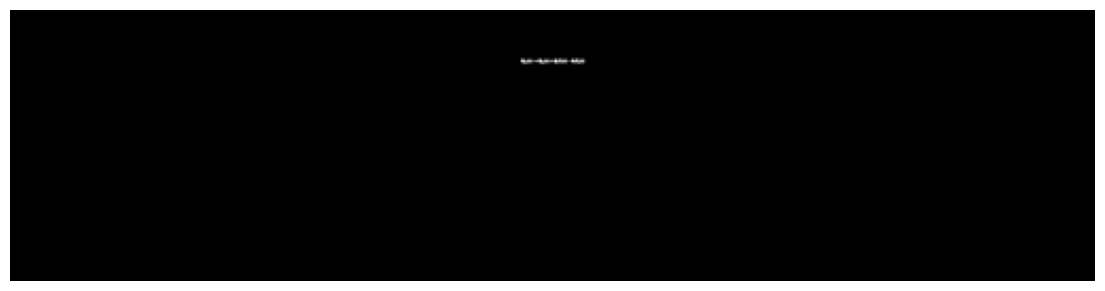

Train batches: 595
Validation batches: 60
Test batches: 30
Images: (32, 128, 512, 1)
Decoder: (32, 123)
Target: (32, 123)
CNN feature map: (None, 8, 32, 256)
Encoder output: (None, 256, 256)
Initial state: (None, 512)
Decoder states: (None, 123, 512)
Context: (None, 123, 256)
Attention: (None, 123, 256)
(None, 123, 768)
Predictions: (None, 123, 3617)


Model: "Image_to_LaTeX"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 512,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 256,   │        320 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 256,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 128,   │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 64,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 32,     │    295,168 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 32,     │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_features    │ (None, 256, 256)  │          0 │ batch_normalizat… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 123)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_image_featu… │ (None, 256)       │          0 │ spatial_features… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latex_embedding     │ (None, 123, 256)  │    925,952 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_decoder_st… │ (None, 512)       │    131,584 │ global_image_fea… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru (GRU)   │ [(None, 123,      │  1,182,720 │ latex_embedding[… │
│                     │ 512), (None,      │            │ initial_decoder_… │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 123,      │    393,728 │ spatial_features… │
│ (SpatialBahdanauAt… │ 256), (None, 123, │            │ decoder_gru[0][0] │
│                     │ 256)]             │            │                 

 Total params: 5,272,993 (20.11 MB)

 Trainable params: 5,272,033 (20.11 MB)

 Non-trainable params: 960 (3.75 KB)

Images: (32, 128, 512, 1)
Decoder: (32, 123)
Targets: (32, 123)
Predictions: (32, 123, 3617)
Predictions: (32, 123, 3617)
Attention weights: (32, 123, 256)
Сумма весов первого токена: 1.0


In [ ]:
# 40. Пути к изображениям

def get_image_paths(
    dataframe,
):

    return np.array(
        [
            str(
                image_path_by_name[
                    image_name
                ]
            )
            for image_name
            in dataframe["image"]
        ]
    )


train_image_paths = get_image_paths(
    train_df
)

val_image_paths = get_image_paths(
    val_df
)

test_image_paths = get_image_paths(
    test_df
)

print(
    "Train:",
    train_image_paths.shape
)

print(
    "Validation:",
    val_image_paths.shape
)

print(
    "Test:",
    test_image_paths.shape
)


# 41. Decoder input и target

train_decoder_inputs = (
    train_sequences[
        :,
        :-1
    ]
)

train_targets = (
    train_sequences[
        :,
        1:
    ]
)

val_decoder_inputs = (
    val_sequences[
        :,
        :-1
    ]
)

val_targets = (
    val_sequences[
        :,
        1:
    ]
)

test_decoder_inputs = (
    test_sequences[
        :,
        :-1
    ]
)

test_targets = (
    test_sequences[
        :,
        1:
    ]
)

print(
    "Train decoder:",
    train_decoder_inputs.shape
)

print(
    "Train target:",
    train_targets.shape
)



# 42. Подготовка изображения

def load_formula_image(
    image_path,
):

    image = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_png(
        image,
        channels=1,
    )

    image = tf.image.convert_image_dtype(
        image,
        tf.float32,
    )

    # Делаем фон равным 0,
    # а символы близкими к 1
    image = (
        1.0
        - image
    )

    image = tf.image.resize_with_pad(
        image,
        IMG_HEIGHT,
        IMG_WIDTH,
        antialias=True,
    )

    return image





# 43. Проверка изображения

sample_image = (
    load_formula_image(
        train_image_paths[0]
    )
)

print(
    "Shape:",
    sample_image.shape
)

print(
    "Min:",
    float(
        tf.reduce_min(
            sample_image
        )
    )
)

print(
    "Max:",
    float(
        tf.reduce_max(
            sample_image
        )
    )
)

plt.figure(
    figsize=(14, 4)
)

plt.imshow(
    sample_image[
        :,
        :,
        0
    ],
    cmap="gray",
)

plt.axis(
    "off"
)

plt.show()



# 44. Подготовка примера

def prepare_sample(
    image_path,
    decoder_input,
    target,
):

    image = load_formula_image(
        image_path
    )

    inputs = {
        "image":
            image,

        "decoder_input":
            decoder_input,
    }

    return (
        inputs,
        target,
    )



# 45. Создание Dataset

def create_dataset(
    image_paths,
    decoder_inputs,
    targets,
    training=False,
):

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                image_paths,
                decoder_inputs,
                targets,
            )
        )
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=min(
                5000,
                len(image_paths),
            ),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        prepare_sample,
        num_parallel_calls=
            tf.data.AUTOTUNE,
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset




# 46. Датасеты

train_dataset = create_dataset(
    train_image_paths,
    train_decoder_inputs,
    train_targets,
    training=True,
)

val_dataset = create_dataset(
    val_image_paths,
    val_decoder_inputs,
    val_targets,
    training=False,
)

test_dataset = create_dataset(
    test_image_paths,
    test_decoder_inputs,
    test_targets,
    training=False,
)

print(
    "Train batches:",
    len(train_dataset)
)

print(
    "Validation batches:",
    len(val_dataset)
)

print(
    "Test batches:",
    len(test_dataset)
)




# 47. Проверка батча

for (
    batch_inputs,
    batch_targets,
) in train_dataset.take(1):

    print(
        "Images:",
        batch_inputs[
            "image"
        ].shape
    )

    print(
        "Decoder:",
        batch_inputs[
            "decoder_input"
        ].shape
    )

    print(
        "Target:",
        batch_targets.shape
    )




# 48. CNN Encoder

image_input = tf.keras.layers.Input(
    shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        1,
    ),
    name="image",
)

x = tf.keras.layers.Conv2D(
    32,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
)(image_input)

x = tf.keras.layers.BatchNormalization()(
    x
)

x = tf.keras.layers.Conv2D(
    64,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
)(x)

x = tf.keras.layers.BatchNormalization()(
    x
)

x = tf.keras.layers.Conv2D(
    128,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
)(x)

x = tf.keras.layers.BatchNormalization()(
    x
)

x = tf.keras.layers.Conv2D(
    256,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
)(x)

x = tf.keras.layers.BatchNormalization()(
    x
)

print(
    "CNN feature map:",
    x.shape
)




# 49. Пространственные признаки

encoder_features = (
    tf.keras.layers.Reshape(
        (
            8 * 32,
            256,
        ),
        name="spatial_features",
    )(
        x
    )
)

print(
    "Encoder output:",
    encoder_features.shape
)



# 50. Начальное состояние GRU

global_image_features = (
    tf.keras.layers.GlobalAveragePooling1D(
        name="global_image_features",
    )(
        encoder_features
    )
)

initial_state = (
    tf.keras.layers.Dense(
        UNITS,
        activation="tanh",
        name="initial_decoder_state",
    )(
        global_image_features
    )
)

print(
    "Initial state:",
    initial_state.shape
)



# 51. Вход декодера

decoder_input = (
    tf.keras.layers.Input(
        shape=(
            MAX_SEQ_LEN - 1,
        ),
        dtype=tf.int32,
        name="decoder_input",
    )
)


# 52. Embedding

embedding_layer = (
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        mask_zero=False,
        name="latex_embedding",
    )
)

decoder_embedding = (
    embedding_layer(
        decoder_input
    )
)



# 53. GRU Decoder

decoder_gru = (
    tf.keras.layers.GRU(
        UNITS,
        return_sequences=True,
        return_state=True,
        name="decoder_gru",
    )
)

(
    decoder_states,
    final_state,
) = decoder_gru(
    decoder_embedding,
    initial_state=
        initial_state,
)

print(
    "Decoder states:",
    decoder_states.shape
)



# 54. Bahdanau Attention

class SpatialBahdanauAttention(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        units,
        **kwargs,
    ):

        super().__init__(
            **kwargs
        )

        self.units = units

        self.W_encoder = (
            tf.keras.layers.Dense(
                units,
                use_bias=False,
            )
        )

        self.W_decoder = (
            tf.keras.layers.Dense(
                units,
                use_bias=False,
            )
        )

        self.V = (
            tf.keras.layers.Dense(
                1,
                use_bias=False,
            )
        )


    def call(
        self,
        inputs,
    ):

        encoder_features, decoder_states = (
            inputs
        )

        encoder_projection = (
            self.W_encoder(
                encoder_features
            )
        )

        decoder_projection = (
            self.W_decoder(
                decoder_states
            )
        )

        encoder_projection = (
            tf.expand_dims(
                encoder_projection,
                axis=1,
            )
        )

        decoder_projection = (
            tf.expand_dims(
                decoder_projection,
                axis=2,
            )
        )

        score = self.V(
            tf.nn.tanh(
                encoder_projection
                + decoder_projection
            )
        )

        score = tf.squeeze(
            score,
            axis=-1,
        )

        attention_weights = (
            tf.nn.softmax(
                score,
                axis=-1,
            )
        )

        context = tf.einsum(
            "bts,bsd->btd",
            attention_weights,
            encoder_features,
        )

        return (
            context,
            attention_weights,
        )


    def get_config(
        self,
    ):

        config = super().get_config()

        config.update(
            {
                "units":
                    self.units
            }
        )

        return config




  # 55. Spatial Attention

attention_layer = (
    SpatialBahdanauAttention(
        ATTENTION_UNITS,
        name="bahdanau_attention",
    )
)

(
    context_vectors,
    attention_weights,
) = attention_layer(
    [
        encoder_features,
        decoder_states,
    ]
)

print(
    "Context:",
    context_vectors.shape
)

print(
    "Attention:",
    attention_weights.shape
)



# 56. Context + Decoder

combined_features = (
    tf.keras.layers.Concatenate(
        axis=-1,
        name="context_decoder_concat",
    )(
        [
            decoder_states,
            context_vectors,
        ]
    )
)

print(
    combined_features.shape
)



# 57. Предсказание токенов

classifier_hidden = (
    tf.keras.layers.Dense(
        512,
        activation="relu",
        name="classifier_hidden",
    )(
        combined_features
    )
)

classifier_hidden = (
    tf.keras.layers.Dropout(
        0.2,
        name="classifier_dropout",
    )(
        classifier_hidden
    )
)

token_predictions = (
    tf.keras.layers.Dense(
        VOCAB_SIZE,
        activation="softmax",
        name="latex_tokens",
    )(
        classifier_hidden
    )
)

print(
    "Predictions:",
    token_predictions.shape
)




# 58. Полная модель

formula_model = tf.keras.Model(
    inputs=[
        image_input,
        decoder_input,
    ],
    outputs=
        token_predictions,
    name="Image_to_LaTeX",
)

formula_model.summary()



# 59. Модель визуализации внимания

attention_model = tf.keras.Model(
    inputs=[
        image_input,
        decoder_input,
    ],
    outputs=[
        token_predictions,
        attention_weights,
    ],
    name="Image_to_LaTeX_Attention",
)



# 60. Masked loss

loss_object = (
    tf.keras.losses
    .SparseCategoricalCrossentropy(
        reduction="none"
    )
)


def masked_loss(
    y_true,
    y_pred,
):

    loss = loss_object(
        y_true,
        y_pred,
    )

    mask = tf.not_equal(
        y_true,
        PAD_ID,
    )

    mask = tf.cast(
        mask,
        loss.dtype,
    )

    loss = (
        loss
        * mask
    )

    return (
        tf.reduce_sum(
            loss
        )
        /
        tf.reduce_sum(
            mask
        )
    )





# 61. Masked accuracy

def masked_accuracy(
    y_true,
    y_pred,
):

    predicted = tf.argmax(
        y_pred,
        axis=-1,
        output_type=
            y_true.dtype,
    )

    matches = tf.equal(
        y_true,
        predicted,
    )

    mask = tf.not_equal(
        y_true,
        PAD_ID,
    )

    matches = tf.logical_and(
        matches,
        mask,
    )

    matches = tf.cast(
        matches,
        tf.float32,
    )

    mask = tf.cast(
        mask,
        tf.float32,
    )

    return (
        tf.reduce_sum(
            matches
        )
        /
        tf.reduce_sum(
            mask
        )
    )



# 62. Компиляция

optimizer = (
    tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
)

formula_model.compile(
    optimizer=optimizer,
    loss=masked_loss,
    metrics=[
        masked_accuracy
    ],
)



# 63. Проверка модели

for (
    batch_inputs,
    batch_targets,
) in train_dataset.take(1):

    predictions = formula_model(
        batch_inputs,
        training=False,
    )

    print(
        "Images:",
        batch_inputs[
            "image"
        ].shape
    )

    print(
        "Decoder:",
        batch_inputs[
            "decoder_input"
        ].shape
    )

    print(
        "Targets:",
        batch_targets.shape
    )

    print(
        "Predictions:",
        predictions.shape
    )



# 64. Проверка Attention

for (
    batch_inputs,
    batch_targets,
) in train_dataset.take(1):

    (
        predictions,
        weights,
    ) = attention_model(
        batch_inputs,
        training=False,
    )

    print(
        "Predictions:",
        predictions.shape
    )

    print(
        "Attention weights:",
        weights.shape
    )

    print(
        "Сумма весов первого токена:",
        float(
            tf.reduce_sum(
                weights[
                    0,
                    0,
                    :
                ]
            )
        )
    )






In [ ]:
# 65. Размер батча для обучения

BATCH_SIZE = 16

train_dataset = create_dataset(
    train_image_paths,
    train_decoder_inputs,
    train_targets,
    training=True,
)

val_dataset = create_dataset(
    val_image_paths,
    val_decoder_inputs,
    val_targets,
    training=False,
)

test_dataset = create_dataset(
    test_image_paths,
    test_decoder_inputs,
    test_targets,
    training=False,
)

print(
    "Train batches:",
    len(train_dataset)
)

print(
    "Validation batches:",
    len(val_dataset)
)

print(
    "Test batches:",
    len(test_dataset)
)



# 66. Callbacks

CHECKPOINT_PATH = (
    "/content/"
    "im2latex_best.weights.h5"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=1,
    ),
]



# 67. Обучение модели

history = formula_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)




# 68. Лучшие веса

formula_model.load_weights(
    CHECKPOINT_PATH
)

print(
    "Лучшие веса загружены."
)



# 69. График Loss

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history.history[
        "loss"
    ],
    label="Train",
)

plt.plot(
    history.history[
        "val_loss"
    ],
    label="Validation",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Image-to-LaTeX: Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()



# 70. График Accuracy

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history.history[
        "masked_accuracy"
    ],
    label="Train",
)

plt.plot(
    history.history[
        "val_masked_accuracy"
    ],
    label="Validation",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Masked accuracy"
)

plt.title(
    "Image-to-LaTeX: Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()



# 71. Encoder для inference

encoder_inference_model = (
    tf.keras.Model(
        inputs=image_input,
        outputs=[
            encoder_features,
            initial_state,
        ],
        name="latex_encoder_inference",
    )
)



# 72. Проверка Encoder

example_image = load_formula_image(
    test_image_paths[0]
)

(
    example_features,
    example_state,
) = encoder_inference_model(
    tf.expand_dims(
        example_image,
        axis=0,
    ),
    training=False,
)

print(
    "Spatial features:",
    example_features.shape
)

print(
    "Decoder state:",
    example_state.shape
)



# 73. Входы inference-декодера

step_token_input = (
    tf.keras.layers.Input(
        shape=(1,),
        dtype=tf.int32,
        name="step_token",
    )
)

step_state_input = (
    tf.keras.layers.Input(
        shape=(UNITS,),
        dtype=tf.float32,
        name="step_state",
    )
)

step_encoder_features = (
    tf.keras.layers.Input(
        shape=(
            8 * 32,
            256,
        ),
        dtype=tf.float32,
        name="step_encoder_features",
    )
)



# 74. Embedding inference

step_embedding = (
    formula_model
    .get_layer(
        "latex_embedding"
    )(
        step_token_input
    )
)



# 75. Один шаг GRU

(
    step_decoder_output,
    step_next_state,
) = (
    formula_model
    .get_layer(
        "decoder_gru"
    )(
        step_embedding,
        initial_state=
            step_state_input,
    )
)



# 76. Attention одного шага

(
    step_context,
    step_attention,
) = (
    formula_model
    .get_layer(
        "bahdanau_attention"
    )(
        [
            step_encoder_features,
            step_decoder_output,
        ]
    )
)



# 77. Объединение признаков

step_combined = (
    formula_model
    .get_layer(
        "context_decoder_concat"
    )(
        [
            step_decoder_output,
            step_context,
        ]
    )
)



# 78. Предсказание следующего токена

step_hidden = (
    formula_model
    .get_layer(
        "classifier_hidden"
    )(
        step_combined
    )
)

step_hidden = (
    formula_model
    .get_layer(
        "classifier_dropout"
    )(
        step_hidden
    )
)

step_predictions = (
    formula_model
    .get_layer(
        "latex_tokens"
    )(
        step_hidden
    )
)


# 79. Decoder inference model

decoder_inference_model = (
    tf.keras.Model(
        inputs=[
            step_token_input,
            step_state_input,
            step_encoder_features,
        ],
        outputs=[
            step_predictions,
            step_next_state,
            step_attention,
        ],
        name="latex_decoder_inference",
    )
)



# 80. Проверка inference-декодера

test_token = tf.constant(
    [
        [
            START_ID
        ]
    ],
    dtype=tf.int32,
)

(
    test_predictions,
    test_state,
    test_attention,
) = decoder_inference_model(
    [
        test_token,
        example_state,
        example_features,
    ],
    training=False,
)

print(
    "Predictions:",
    test_predictions.shape
)

print(
    "State:",
    test_state.shape
)

print(
    "Attention:",
    test_attention.shape
)

print(
    "Attention sum:",
    float(
        tf.reduce_sum(
            test_attention[
                0,
                0,
                :
            ]
        )
    )
)



# 81. Генерация LaTeX

def generate_latex(
    image_name,
):

    image_path = (
        image_path_by_name[
            image_name
        ]
    )

    image = load_formula_image(
        str(
            image_path
        )
    )

    image_batch = tf.expand_dims(
        image,
        axis=0,
    )

    (
        encoder_output,
        decoder_state,
    ) = encoder_inference_model(
        image_batch,
        training=False,
    )

    current_token = tf.constant(
        [
            [
                START_ID
            ]
        ],
        dtype=tf.int32,
    )

    generated_ids = []
    attention_history = []

    for step in range(
        MAX_SEQ_LEN - 1
    ):

        (
            predictions,
            decoder_state,
            attention,
        ) = decoder_inference_model(
            [
                current_token,
                decoder_state,
                encoder_output,
            ],
            training=False,
        )

        probabilities = (
            predictions[
                0,
                0,
                :
            ]
            .numpy()
            .copy()
        )

        # Не генерируем служебные токены
        probabilities[
            PAD_ID
        ] = -1.0

        probabilities[
            START_ID
        ] = -1.0

        predicted_id = int(
            np.argmax(
                probabilities
            )
        )

        if predicted_id == END_ID:
            break

        generated_ids.append(
            predicted_id
        )

        attention_history.append(
            attention[
                0,
                0,
                :
            ].numpy()
        )

        current_token = tf.constant(
            [
                [
                    predicted_id
                ]
            ],
            dtype=tf.int32,
        )

    generated_tokens = [
        id_to_token.get(
            token_id,
            UNK_TOKEN,
        )
        for token_id
        in generated_ids
    ]

    latex = " ".join(
        generated_tokens
    )

    if attention_history:

        attention_history = (
            np.stack(
                attention_history
            )
        )

    else:

        attention_history = (
            np.empty(
                (
                    0,
                    256,
                ),
                dtype=np.float32,
            )
        )

    return {
        "latex":
            latex,

        "tokens":
            generated_tokens,

        "attention":
            attention_history,

        "image":
            image.numpy(),
    }



# 82. Первый тест

example_name = (
    test_df[
        "image"
    ].iloc[
        0
    ]
)

result = generate_latex(
    example_name
)

print(
    "Image:",
    example_name
)

print()

print(
    "Оригинальный LaTeX:"
)

print(
    test_df[
        "formula_clean"
    ].iloc[
        0
    ]
)

print()

print(
    "Предсказанный LaTeX:"
)

print(
    result[
        "latex"
    ]
)

print()

print(
    "Количество токенов:",
    len(
        result[
            "tokens"
        ]
    )
)

print(
    "Attention shape:",
    result[
        "attention"
    ].shape
)



# 83. Изображение и результат

plt.figure(
    figsize=(14, 4)
)

plt.imshow(
    result[
        "image"
    ][
        :,
        :,
        0
    ],
    cmap="gray",
)

plt.axis(
    "off"
)

plt.title(
    result[
        "latex"
    ][:180],
    fontsize=10,
)

plt.show()




# 84. Карта внимания

def resize_attention(
    attention_vector,
):

    attention_map = (
        attention_vector
        .reshape(
            8,
            32,
        )
    )

    attention_map = tf.image.resize(
        attention_map[
            ...,
            np.newaxis
        ],
        (
            IMG_HEIGHT,
            IMG_WIDTH,
        ),
        method="bilinear",
    )

    attention_map = (
        attention_map[
            :,
            :,
            0
        ].numpy()
    )

    maximum = (
        attention_map.max()
    )

    if maximum > 0:

        attention_map = (
            attention_map
            / maximum
        )

    return attention_map





# 85. Attention по токенам

def show_attention(
    result,
    max_tokens=8,
):

    tokens = result[
        "tokens"
    ]

    attention = result[
        "attention"
    ]

    if len(tokens) == 0:

        print(
            "Модель не сгенерировала токены."
        )

        return

    count = min(
        max_tokens,
        len(tokens),
    )

    token_indices = np.linspace(
        0,
        len(tokens) - 1,
        count,
        dtype=int,
    )

    plt.figure(
        figsize=(
            16,
            count * 2.5,
        )
    )

    for plot_index, token_index in enumerate(
        token_indices,
        start=1,
    ):

        attention_map = resize_attention(
            attention[
                token_index
            ]
        )

        plt.subplot(
            count,
            1,
            plot_index,
        )

        plt.imshow(
            result[
                "image"
            ][
                :,
                :,
                0
            ],
            cmap="gray",
        )

        plt.imshow(
            attention_map,
            alpha=0.55,
            cmap="jet",
        )

        plt.title(
            f"Token {token_index + 1}: "
            f"{tokens[token_index]}"
        )

        plt.axis(
            "off"
        )

    plt.tight_layout()
    plt.show()



# 86. Демонстрация Attention

show_attention(
    result,
    max_tokens=8,
)



# 87. Матрица Attention

def show_attention_matrix(
    result,
):

    attention = result[
        "attention"
    ]

    tokens = result[
        "tokens"
    ]

    if len(tokens) == 0:
        return

    plt.figure(
        figsize=(
            16,
            min(
                12,
                4
                + len(tokens) * 0.15,
            ),
        )
    )

    plt.imshow(
        attention,
        aspect="auto",
    )

    plt.xlabel(
        "Пространственная область CNN"
    )

    plt.ylabel(
        "Шаг декодера"
    )

    plt.title(
        "Bahdanau Attention"
    )

    if len(tokens) <= 40:

        plt.yticks(
            range(
                len(tokens)
            ),
            tokens,
        )

    plt.colorbar(
        label="Attention weight"
    )

    plt.show()




# 88. Матрица внимания

show_attention_matrix(
    result
)


# 89. Тестовые примеры

demo_df = (
    test_df
    .sample(
        10,
        random_state=SEED,
    )
    .reset_index(
        drop=True
    )
)

demo_results = []



# 90. Генерация примеров

for index, row in (
    demo_df.iterrows()
):

    print(
        f"Обработка "
        f"{index + 1}/"
        f"{len(demo_df)}"
    )

    prediction = generate_latex(
        row[
            "image"
        ]
    )

    demo_results.append(
        {
            "image":
                row[
                    "image"
                ],

            "original":
                row[
                    "formula_clean"
                ],

            "predicted":
                prediction[
                    "latex"
                ],
        }
    )



# 91. Таблица результатов

results_df = pd.DataFrame(
    demo_results
)

results_df





Train batches: 1190
Validation batches: 119
Test batches: 60
Epoch 1/15
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - loss: 3.5397 - masked_accuracy: 0.3111
Epoch 1: val_loss improved from None to 2.98820, saving model to /content/im2latex_best.weights.h5

Epoch 1: finished saving model to /content/im2latex_best.weights.h5
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 650s 539ms/step - loss: 3.0017 - masked_accuracy: 0.3817 - val_loss: 2.9882 - val_masked_accuracy: 0.3888 - learning_rate: 0.0010
Epoch 2/15
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - loss: 2.5273 - masked_accuracy: 0.4508
Epoch 2: val_loss did not improve from 2.98820
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 610s 512ms/step - loss: 2.4758 - masked_accuracy: 0.4579 - val_loss: 10.2869 - val_masked_accuracy: 0.2886 - learning_rate: 0.0010
Epoch 3/15
1008/1190 ━━━━━━━━━━━━━━━━━━━━ 1:23 459ms/step - loss: 2.3349 - masked_accuracy: 0.4772